# 07. 메모리(Memory)와 체크포인터(Checkpointer)

> LangGraph는 매 superstep마다 상태를 저장해 멀티턴 대화와 실패 복구를 가능하게 해요. `MemorySaver` + `thread_id` 만으로 어떻게 영속적인 챗봇이 만들어지는지 봐요.

LangGraph에서 그래프는 기본적으로 **상태 비보존(stateless)** 방식으로 동작해요. 즉, 각 호출이 독립적이기 때문에 이전 대화 내용을 기억하지 못해요. 멀티턴(multi-turn) 대화를 구현하려면 **체크포인터(Checkpointer)** 가 필요해요.

체크포인터는 그래프의 각 실행 단계 후 상태(State)를 자동으로 저장하고, 동일한 `thread_id`로 재호출할 때 저장된 상태를 불러와 대화를 이어갑니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `MemorySaver`를 생성하고 그래프에 체크포인터로 적용할 수 있어요
2. `thread_id`를 사용해 멀티턴 대화 세션을 구분하고 관리할 수 있어요
3. `RunnableConfig`의 `recursion_limit`과 `configurable`을 올바르게 설정할 수 있어요
4. `get_state(config)`로 저장된 스냅샷(values, config, next, metadata)을 조회할 수 있어요
5. `thread_id` 변경으로 독립 세션을 생성하고 차이를 실습할 수 있어요

## 사전 지식

- `06-Tools-Integration.ipynb`: Tool Binding, ToolNode, tools_condition, Conditional Edges
- `05-ChatBot.ipynb`: StateGraph, add_messages 리듀서, 기본 챗봇 구성
- `04-StateGraph-Basics.ipynb`: StateGraph, State, Node, Edge 개념

## 체크포인터 개념과 아키텍처

### 왜 체크포인터가 필요한가요?

LangGraph의 그래프는 기본적으로 상태 비보존 방식이에요. 사용자가 "제 이름은 홍길동이에요"라고 말하고, 다음 호출에서 "제 이름이 뭐죠?"라고 물어보면 답을 모르는 상태가 됩니다.

> **비유: 메모장 없는 상담원 vs 메모장 있는 상담원**
>
> 체크포인터가 없는 그래프는 **메모장 없이 전화 상담하는 직원**과 같아요. 전화를 끊고 다시 걸면 이전에 무슨 이야기를 했는지 전혀 기억 못 해요. 체크포인터를 추가하면 **메모장에 대화 내용을 기록하는 직원**이 돼요. 같은 고객(같은 `thread_id`)이 다시 전화하면 메모장을 펼쳐서 이전 대화를 떠올릴 수 있어요.

체크포인터를 추가하면:
- 각 노드 실행 후 **상태(State)를 자동 저장**해요
- `thread_id`로 **대화 세션을 구분**해요
- 동일한 `thread_id` 재호출 시 **이전 상태를 복원**해요

### 체크포인터 종류

| 체크포인터 | 저장 방식 | 용도 |
|------------|-----------|------|
| `MemorySaver` | 메모리(RAM) | 개발/테스트 환경 |
| `SqliteSaver` | SQLite 파일 | 단일 서버 영구 저장 |
| `PostgresSaver` | PostgreSQL DB | 프로덕션 환경 |
| `RedisSaver` | Redis | 고성능 분산 환경 |

> 💡 **실무 팁**: 개발/테스트에는 `MemorySaver`를 사용하고, 프로덕션에는 반드시 영구 저장 체크포인터로 교체하세요. `MemorySaver`는 프로세스 종료 시 모든 상태가 사라져요.

### 전체 아키텍처

```mermaid
flowchart TD
    U(["사용자 입력<br>User Input"]):::input
    C{"configurable<br>thread_id"}:::process
    START(["START"]):::input
    chatbot["chatbot 노드<br>LLM + Tools"]:::process
    tools["tools 노드<br>ToolNode"]:::process
    END_NODE(["END"]):::output
    MEM[("MemorySaver<br>체크포인트 저장")]:::storage

    U --> C
    C -->|"thread_id: 1<br>(세션 유지)"| START
    START --> chatbot
    chatbot -->|"도구 필요?"| tools
    tools --> chatbot
    chatbot --> END_NODE
    chatbot -.->|"상태 저장"| MEM
    tools -.->|"상태 저장"| MEM
    MEM -.->|"상태 복원<br>(같은 thread_id)"| chatbot

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 설명 |
|-----------|------|------|
| `MemorySaver` | 체크포인터 | 메모리에 상태 저장/복원 |
| `thread_id` | 세션 식별자 | 대화 세션을 고유하게 구분 |
| `RunnableConfig` | 실행 설정 | thread_id, recursion_limit 전달 |
| `get_state(config)` | 스냅샷 조회 | 저장된 상태 확인 |
| `StateSnapshot` | 상태 스냅샷 | values, config, next, metadata 포함 |

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 API 키를 읽어요)
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os

# LangSmith 추적 설정 (선택 사항)
# 실행 흐름을 LangSmith에서 시각적으로 확인할 수 있어요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-Part02-Memory"

## 1. MemorySaver 체크포인터 생성

`MemorySaver`는 LangGraph에서 가장 간단한 형태의 체크포인터예요. 상태를 파이썬 프로세스의 메모리에 저장합니다.

> 🔑 **핵심 개념**: `MemorySaver`는 **개발과 테스트 전용**이에요. 서버 재시작 시 모든 대화 기록이 사라지기 때문에 프로덕션에서는 `PostgresSaver` 같은 영구 저장소를 사용해야 해요.

> 💡 **공식 이름 안내**: LangGraph 최신 문서는 동일한 클래스를 `InMemorySaver`로 표기해요. `MemorySaver`는 호환을 위한 별칭이며, `from langgraph.checkpoint.memory import InMemorySaver`를 사용해도 동일하게 동작해요.

> 🎯 **강의 포인트**: `MemorySaver()` 호출만으로 체크포인터가 준비돼요. 복잡한 데이터베이스 설정 없이 바로 상태 저장을 테스트할 수 있어요.

In [3]:
# LangGraph 인메모리 체크포인터를 가져와요
from langgraph.checkpoint.memory import MemorySaver

# ---------------------------------------------------
# 인메모리 체크포인터 생성
# ---------------------------------------------------
# 개발/테스트 환경에 적합해요
# 프로세스 종료 시 모든 상태가 사라져요
memory = MemorySaver()

print("체크포인터 생성 완료:", type(memory))

체크포인터 생성 완료: <class 'langgraph.checkpoint.memory.InMemorySaver'>


## 2. 메모리가 있는 에이전트 그래프 구성

이전 노트북(`06-Tools-Integration.ipynb`)에서 만든 Tool + ToolNode + tools_condition 패턴에 체크포인터를 추가해요. 여기서는 `TavilySearch`를 웹 검색 도구로 사용해요.

> 🔑 **핵심 개념**: 그래프 구성 자체는 변하지 않아요. **`compile()` 시점에 `checkpointer=memory`를 전달**하는 것만으로 모든 노드의 실행 후 상태가 자동 저장돼요.

> ⚠️ **자주 하는 실수**: `checkpointer` 없이 컴파일된 그래프에 `thread_id`를 전달해도 아무 효과가 없어요. 반드시 `compile(checkpointer=...)` 단계에서 설정해야 해요.

### checkpointer 유무 비교

| 구분 | `compile()` | `compile(checkpointer=memory)` |
|------|-------------|-------------------------------|
| 대화 기억 | 매번 새로운 대화 | `thread_id`로 대화 이어가기 |
| 상태 저장 | 실행 후 상태 소멸 | 노드 실행마다 자동 저장 |
| `get_state()` | 사용 불가 | 스냅샷 조회 가능 |
| HITL(사람 개입) | 구현 불가 | `interrupt`로 중단/재개 가능 |

In [4]:
# ---------------------------------------------------
# TavilySearch: AI 에이전트용 웹 검색 도구
# ---------------------------------------------------
# langchain-tavily 패키지에서 실제 웹 검색 도구를 가져와요
from langchain_tavily import TavilySearch

# TavilySearch 인스턴스 생성
# max_results: 반환할 검색 결과 수
search_tool = TavilySearch(max_results=3)

tools = [search_tool]
print(f"도구 등록 완료: {[t.name for t in tools]}")

도구 등록 완료: ['tavily_search']


In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# ---------------------------------------------------
# 1. 상태(State) 정의
# ---------------------------------------------------
# add_messages 리듀서: 새 메시지를 기존 리스트에 추가해요
class State(TypedDict):
    messages: Annotated[list, add_messages]


# ---------------------------------------------------
# 2. LLM 초기화 및 도구 바인딩
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율적)
# 변경 옵션: "anthropic:claude-sonnet-4-5", "google_genai:gemini-2.0-flash"
llm = init_chat_model("openai:gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)  # 도구를 LLM에 연결


# ---------------------------------------------------
# 3. 노드 함수 정의
# ---------------------------------------------------
def chatbot(state: State):
    """챗봇 노드: 현재 메시지를 LLM에 전달하고 응답을 반환해요"""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# ---------------------------------------------------
# 4. 그래프 구성
# ---------------------------------------------------
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# 엣지 추가
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)  # 도구 필요 여부 분기
graph_builder.add_edge("tools", "chatbot")  # 도구 실행 후 챗봇으로 복귀

# 그래프 구성 완료

### 체크포인터를 적용하여 그래프 컴파일

핵심은 `compile()` 호출 시 `checkpointer=memory`를 전달하는 것이에요.

In [6]:
# ---------------------------------------------------
# 그래프 컴파일 (체크포인터 적용)
# ---------------------------------------------------
# checkpointer=memory 를 전달하면:
# - 각 노드 실행 후 State가 자동 저장돼요
# - 동일한 thread_id 재호출 시 이전 State를 복원해요
graph = graph_builder.compile(checkpointer=memory)

# 그래프 컴파일 완료 (체크포인터 적용됨)

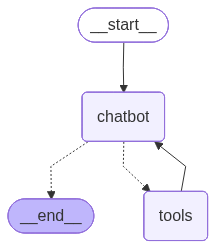

In [7]:
# 그래프 흐름: START → chatbot → tools → chatbot → ... → END
# chatbot 노드: LLM이 사용자 메시지를 처리하고 도구 호출을 결정해요
# tools 노드: tool_call이 있으면 도구를 실행해요
# 조건부 엣지: tools_condition이 도구 호출 유무로 분기해요
from IPython.display import Image, display

# 그래프 구조 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

## 3. RunnableConfig 설정과 thread_id

`RunnableConfig`는 그래프 실행 시 전달하는 실행 설정이에요. 체크포인터와 함께 사용할 때 두 가지 중요한 설정이 있어요:

| 설정 | 키 | 설명 |
|------|----|------|
| `recursion_limit` | 최상위 키 | 최대 방문 노드 수 (무한 루프 방지) |
| `configurable.thread_id` | `configurable` 내부 | 대화 세션 식별자 |

> 🔑 **핵심 개념**: `thread_id`는 대화 세션의 **고유 식별자**예요. 같은 `thread_id` = 같은 대화 세션(이전 기억 유지), 다른 `thread_id` = 완전히 새로운 독립 세션이에요. 카카오톡 채팅방에 비유하면, 각 `thread_id`는 별도의 채팅방이에요. "친구 A와의 채팅방"과 "친구 B와의 채팅방"은 대화 내용이 완전히 분리되어 있는 것처럼요.

> 🎯 **강의 포인트**: 실무에서는 사용자 ID나 UUID를 `thread_id`로 사용해요. 각 사용자의 대화 이력이 완전히 분리되어 관리됩니다.

In [8]:
from langchain_core.runnables import RunnableConfig

config_thread1 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": "user_001"},  # 사용자 1의 세션
)

# Config 설정 완료:
print(f"  - recursion_limit: {config_thread1.get('recursion_limit')}")
print(f"  - thread_id: {config_thread1.get('configurable', {}).get('thread_id')}")

  - recursion_limit: 10
  - thread_id: user_001


## 4. 멀티턴 대화 테스트

이제 체크포인터가 실제로 동작하는지 확인해볼게요. 첫 번째 대화에서 이름을 알려주고, 두 번째 대화에서 이름을 물어봐요.

> 🎯 **강의 포인트**: 이 테스트가 체크포인터의 핵심 가치를 보여줘요. 동일한 `thread_id`를 사용하면 LLM이 이전 메시지 전체를 컨텍스트로 받기 때문에 연속 대화가 가능해요.

In [9]:
# ---------------------------------------------------
# 첫 번째 대화: 자기소개
# ---------------------------------------------------
inputs = {
    "messages": [
        ("user", "안녕하세요! 저는 김철수라고 해요. LangGraph를 공부 중이에요.")
    ]
}

# ==================================================
# 첫 번째 대화 (thread_id: user_001)
# ==================================================

# 그래프 실행 결과를 스트리밍으로 출력해요
for chunk in graph.stream(inputs, config_thread1, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} 노드 ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- chatbot 노드 ---
================================== Ai Message ==================================

안녕하세요, 김철수님! LangGraph에 대해 공부하고 계시다니 흥미로운 선택입니다. LangGraph는 어떤 측면에 대해 더 알고 싶으신가요? 기술적인 부분부터 활용 사례까지 다양한 정보를 제공할 수 있습니다.


In [10]:
# ---------------------------------------------------
# 두 번째 대화: 이전 대화 기억 확인
# ---------------------------------------------------
# 같은 thread_id(user_001)를 사용하므로
# 이전 대화 내용(이름 소개)이 컨텍스트에 포함돼요
inputs = {"messages": [("user", "제 이름이 뭐라고 했죠?")]}

# ==================================================
# 두 번째 대화 (같은 thread_id: user_001)
# ==================================================

for chunk in graph.stream(inputs, config_thread1, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} 노드 ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- chatbot 노드 ---
================================== Ai Message ==================================

당신의 이름은 김철수입니다!


In [11]:
# ---------------------------------------------------
# 세 번째 대화: 도구 호출 포함
# ---------------------------------------------------
# TavilySearch를 통해 실제 웹 검색을 수행하는 질문이에요
inputs = {"messages": [("user", "구글 CEO가 노벨 화학상을 받았나요?")]}

# ==================================================
# 세 번째 대화 (웹 검색 도구 호출 포함)
# ==================================================

for chunk in graph.stream(inputs, config_thread1, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} 노드 ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- chatbot 노드 ---
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_WW3uxn0mk9xERVcbTkqawUz7)
 Call ID: call_WW3uxn0mk9xERVcbTkqawUz7
  Args:
    query: 구글 CEO 노벨 화학상
    search_depth: basic

--- tools 노드 ---
================================= Tool Message =================================
Name: tavily_search

{"query": "구글 CEO 노벨 화학상", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cio.com/article/3556452/%EA%B5%AC%EA%B8%80-%EB%94%A5%EB%A7%88%EC%9D%B8%EB%93%9C-ceo-%EB%8D%B0%EB%AF%B8%EC%8A%A4-%ED%97%88%EC%82%AC%EB%B9%84%EC%8A%A4-%EB%85%B8%EB%B2%A8-%ED%99%94%ED%95%99%EC%83%81-%EC%88%98%EC%83%81.html", "title": "구글 딥마인드 CEO 데미스 허사비스, 노벨 화학상 수상 - CIO", "content": "이번 노벨 화학상에서 주목받는 인물은 단연 데미스 허사비스다. 허사비스는 2010년 AI 기업 딥마인드를 설립했으며, 구글에 인수된 이후 '알파고' 개발을", "score": 0.85509074, "raw_content": null}, {"url": "https://v.daum.net/v/q7vCnWTNpK?f=p", "title": "구글 딥마인드 CEO 노벨 화학상, 물리학상 이어 화학

## 5. 다른 thread_id로 독립 세션 테스트

`thread_id`를 변경하면 완전히 새로운 독립 세션이 시작돼요. 이전 대화 내용을 전혀 모르는 상태가 됩니다.

> ⚠️ **자주 하는 실수**: "왜 다른 사용자가 제 대화를 볼 수 있나요?" - `thread_id`를 사용자별로 고유하게 설정하지 않으면 대화가 섞일 수 있어요. 실무에서는 반드시 사용자 ID나 UUID로 `thread_id`를 설정하세요.

> 💡 **실무 팁**: 실제 서비스에서는 `uuid.uuid4()`로 생성한 UUID를 `thread_id`로 사용하는 것이 좋아요. 충돌 가능성이 없고 예측 불가능한 ID가 생성돼요.

In [12]:
# ---------------------------------------------------
# 다른 thread_id로 새 세션 생성
# ---------------------------------------------------
config_thread2 = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": "user_002"},  # 다른 사용자의 세션
)

# 이전 대화(user_001)에서 이름을 알려줬지만,
# 새 세션(user_002)은 그 정보를 알 수 없어요
inputs = {"messages": [("user", "제 이름이 뭐라고 했죠?")]}

# ==================================================
# 새 세션 (thread_id: user_002) - 이전 대화 없음
# ==================================================

for chunk in graph.stream(inputs, config_thread2, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} 노드 ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- chatbot 노드 ---
================================== Ai Message ==================================

죄송하지만, 당신의 이름은 제가 기억할 수 없습니다. 당신의 이름을 알려주시면 그에 맞추어 대화할 수 있습니다!


## 6. 스냅샷(Snapshot)으로 저장 상태 조회

지금까지 체크포인터로 대화를 저장하고 이어가는 방법을 배웠어요. 그런데 저장된 상태를 **직접 열어보고** 싶을 때가 있어요. 디버깅할 때, 또는 사용자에게 대화 기록을 보여줄 때요.

`get_state(config)` 메서드를 사용하면 특정 `thread_id`의 현재 저장 상태를 확인할 수 있어요. 반환되는 `StateSnapshot` 객체에는 다음 정보가 담겨 있어요:

| 속성 | 타입 | 설명 |
|------|------|------|
| `values` | dict | 현재 저장된 State 값 (메시지 목록 등) |
| `config` | dict | checkpoint_id, thread_id 등 설정 정보 |
| `next` | tuple | 다음에 실행될 노드 이름 (완료 시 빈 튜플) |
| `metadata` | dict | step 번호, source, parents 등 실행 메타데이터 |

> 🔑 **핵심 개념**: `snapshot.next`가 빈 튜플 `()`이면 그래프 실행이 완료된 상태예요. `('chatbot',)` 처럼 노드 이름이 있으면 해당 노드에서 실행이 중단된 상태 (Human-in-the-Loop 등)입니다.

> 🎯 **강의 포인트**: `checkpoint_id`를 활용하면 과거 특정 시점의 상태로 롤백(Time Travel)할 수 있어요. 이건 다음 노트북 `08-Human-In-The-Loop.ipynb`에서 자세히 다뤄요.

In [13]:
# ---------------------------------------------------
# 스냅샷 조회: thread_id "user_001"의 현재 상태
# ---------------------------------------------------
# get_state()는 해당 thread_id의 가장 최근 체크포인트를 반환해요
snapshot = graph.get_state(config_thread1)

print("스냅샷 타입:", type(snapshot))
# 스냅샷에 포함된 속성들:
for attr in ["values", "config", "next", "metadata"]:
    print(f"  - {attr}: {type(getattr(snapshot, attr)).__name__}")

스냅샷 타입: <class 'langgraph.types.StateSnapshot'>
  - values: dict
  - config: dict
  - next: tuple
  - metadata: dict


In [14]:
# ---------------------------------------------------
# values: 현재 저장된 State 값
# ---------------------------------------------------
# messages 키 아래에 대화 내용 전체가 저장돼요
# ==================================================
# 저장된 메시지 목록 (values['messages'])
# ==================================================

messages = snapshot.values["messages"]
print(f"총 {len(messages)}개의 메시지가 저장됨")
print()

for i, msg in enumerate(messages):
    print(f"[{i+1}] {msg.__class__.__name__}: {str(msg.content)[:80]}...")

총 8개의 메시지가 저장됨

[1] HumanMessage: 안녕하세요! 저는 김철수라고 해요. LangGraph를 공부 중이에요....
[2] AIMessage: 안녕하세요, 김철수님! LangGraph에 대해 공부하고 계시다니 흥미로운 선택입니다. LangGraph는 어떤 측면에 대해 더 알고 싶으신가요...
[3] HumanMessage: 제 이름이 뭐라고 했죠?...
[4] AIMessage: 당신의 이름은 김철수입니다!...
[5] HumanMessage: 구글 CEO가 노벨 화학상을 받았나요?...
[6] AIMessage: ...
[7] ToolMessage: {"query": "구글 CEO 노벨 화학상", "follow_up_questions": null, "answer": null, "images"...
[8] AIMessage: 구글의 CEO인 데미스 허사비스가 노벨 화학상을 수상했습니다. 그는 AI 기업 딥마인드를 설립하고 이후 구글에 인수되어 '알파고' 개발에 참여했...


In [15]:
# ---------------------------------------------------
# config: 체크포인트 설정 정보
# ---------------------------------------------------
# checkpoint_id: 이 시점을 고유하게 식별하는 UUID
# thread_id: 어떤 세션의 체크포인트인지
# ==================================================
# 스냅샷 config 정보
# ==================================================
print(snapshot.config)

{'configurable': {'thread_id': 'user_001', 'checkpoint_ns': '', 'checkpoint_id': '1f14391b-bcf5-6c78-8009-9cc1838a4035'}}


In [16]:
# ---------------------------------------------------
# next: 다음 실행될 노드
# ---------------------------------------------------
# () = 그래프 실행 완료
# ('chatbot',) = chatbot 노드에서 중단 (HITL 등)
# ==================================================
# 다음 실행 노드 (next)
# ==================================================
print("snapshot.next:", snapshot.next)

if snapshot.next == ():
    # -> 그래프 실행이 완료된 상태예요
    pass
else:
    print(f"-> {snapshot.next} 노드에서 실행이 중단된 상태예요")

snapshot.next: ()


In [17]:
# ---------------------------------------------------
# metadata: 실행 메타데이터
# ---------------------------------------------------
# step: 현재까지 실행된 총 스텝 수
# source: 마지막 실행 방식 ("loop", "update" 등)
# parents: 부모 체크포인트 정보 (Time Travel 시 활용)
# ==================================================
# 스냅샷 메타데이터 (metadata)
# ==================================================
for key, value in snapshot.metadata.items():
    print(f"  {key}: {value}")

  source: loop
  step: 9
  parents: {}


## 7. 스냅샷 상세 분석

저장된 각 메시지의 상세 정보를 확인하는 헬퍼 함수를 직접 구현해볼게요.

> 💡 **실무 팁**: 메시지 상세 분석은 디버깅 시 매우 유용해요. 특히 Tool 호출 시 어떤 인수가 전달됐는지, 어떤 응답이 왔는지 확인할 수 있어요.

In [18]:
# ---------------------------------------------------
# 메시지 상세 정보 출력 헬퍼 함수
# ---------------------------------------------------
# 메시지 트리를 직접 출력하는 구현이에요
def print_message_detail(msg, index: int = 0):
    """메시지의 상세 정보를 보기 좋게 출력해요"""
    print(f"\n{'='*40}")
    print(f"[메시지 {index+1}] {msg.__class__.__name__}")
    print(f"{'='*40}")

    # 내용(content) 출력
    content = msg.content
    if isinstance(content, list):
        # Content Block 형식 (Anthropic 등)
        for block in content:
            if isinstance(block, dict) and "text" in block:
                print(f"content: {block['text'][:100]}")
    elif content:
        print(f"content: {str(content)[:100]}")
    else:
        # content: (없음)
        pass

    # 도구 호출 정보 출력
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"tool_calls: {len(msg.tool_calls)}개")
        for tc in msg.tool_calls:
            print(f"  - 도구: {tc['name']}, 인수: {tc['args']}")

    # 도구 호출 ID (ToolMessage)
    if hasattr(msg, "tool_call_id"):
        print(f"tool_call_id: {msg.tool_call_id}")


# 저장된 모든 메시지 상세 출력
# thread_id 'user_001'의 저장된 메시지 상세:
messages = snapshot.values["messages"]
for i, msg in enumerate(messages):
    print_message_detail(msg, i)


[메시지 1] HumanMessage
content: 안녕하세요! 저는 김철수라고 해요. LangGraph를 공부 중이에요.

[메시지 2] AIMessage
content: 안녕하세요, 김철수님! LangGraph에 대해 공부하고 계시다니 흥미로운 선택입니다. LangGraph는 어떤 측면에 대해 더 알고 싶으신가요? 기술적인 부분부터 활용 사례까지 

[메시지 3] HumanMessage
content: 제 이름이 뭐라고 했죠?

[메시지 4] AIMessage
content: 당신의 이름은 김철수입니다!

[메시지 5] HumanMessage
content: 구글 CEO가 노벨 화학상을 받았나요?

[메시지 6] AIMessage
tool_calls: 1개
  - 도구: tavily_search, 인수: {'query': '구글 CEO 노벨 화학상', 'search_depth': 'basic'}

[메시지 7] ToolMessage
content: {"query": "구글 CEO 노벨 화학상", "follow_up_questions": null, "answer": null, "images": [], "results": [{"
tool_call_id: call_WW3uxn0mk9xERVcbTkqawUz7

[메시지 8] AIMessage
content: 구글의 CEO인 데미스 허사비스가 노벨 화학상을 수상했습니다. 그는 AI 기업 딥마인드를 설립하고 이후 구글에 인수되어 '알파고' 개발에 참여했습니다. 올해 노벨 화학상은 단백질 


## 8. 대화 이력 전체 조회

`get_state_history(config)` 메서드를 사용하면 특정 스레드의 **모든 과거 체크포인트**를 순서대로 확인할 수 있어요.

> 🎯 **강의 포인트**: `get_state_history()`는 Time Travel의 기반이 돼요. 특정 `checkpoint_id`를 사용하면 그 시점으로 그래프 상태를 되돌릴 수 있어요. 자세한 내용은 다음 노트북에서 배워요.

In [19]:
# ---------------------------------------------------
# 대화 이력 전체 조회
# ---------------------------------------------------
# get_state_history()는 가장 최근 체크포인트부터 역순으로 반환해요
# ==================================================
# thread_id 'user_001'의 전체 체크포인트 이력
# ==================================================

history = list(graph.get_state_history(config_thread1))
print(f"총 {len(history)}개의 체크포인트가 저장됨\n")

for i, state in enumerate(history):
    # 각 체크포인트의 요약 정보 출력
    checkpoint_id = state.config["configurable"].get("checkpoint_id", "N/A")
    step = state.metadata.get("step", -1)
    msg_count = len(state.values.get("messages", []))
    next_nodes = state.next

    print(f"[체크포인트 {i+1}]")
    print(f"  step: {step}")
    print(f"  저장된 메시지 수: {msg_count}")
    print(f"  다음 노드: {next_nodes if next_nodes else '(완료)'}")
    print(f"  checkpoint_id: {checkpoint_id[:20]}...")
    print()

총 11개의 체크포인트가 저장됨

[체크포인트 1]
  step: 9
  저장된 메시지 수: 8
  다음 노드: (완료)
  checkpoint_id: 1f14391b-bcf5-6c78-8...

[체크포인트 2]
  step: 8
  저장된 메시지 수: 7
  다음 노드: ('chatbot',)
  checkpoint_id: 1f14391b-83f2-6a48-8...

[체크포인트 3]
  step: 7
  저장된 메시지 수: 6
  다음 노드: ('tools',)
  checkpoint_id: 1f14391b-7553-6e60-8...

[체크포인트 4]
  step: 6
  저장된 메시지 수: 5
  다음 노드: ('chatbot',)
  checkpoint_id: 1f14391b-65ac-63d6-8...

[체크포인트 5]
  step: 5
  저장된 메시지 수: 4
  다음 노드: ('__start__',)
  checkpoint_id: 1f14391b-65a6-6936-8...

[체크포인트 6]
  step: 4
  저장된 메시지 수: 4
  다음 노드: (완료)
  checkpoint_id: 1f14391b-658b-6b86-8...

[체크포인트 7]
  step: 3
  저장된 메시지 수: 3
  다음 노드: ('chatbot',)
  checkpoint_id: 1f14391b-5c2e-693a-8...

[체크포인트 8]
  step: 2
  저장된 메시지 수: 2
  다음 노드: ('__start__',)
  checkpoint_id: 1f14391b-5c29-6390-8...

[체크포인트 9]
  step: 1
  저장된 메시지 수: 2
  다음 노드: (완료)
  checkpoint_id: 1f14391b-5bf6-6288-8...

[체크포인트 10]
  step: 0
  저장된 메시지 수: 1
  다음 노드: ('chatbot',)
  checkpoint_id: 1f14391b-4adc-6786-8...

[체크포인트 11]
 

## 실습: 여러 사용자 시뮬레이션

아래 TODO 블록을 완성해 보세요. 두 명의 다른 사용자가 각자 대화하고, 서로의 정보를 기억하지 못하는 것을 확인해요.

In [ ]:
import uuid
from langchain_core.runnables import RunnableConfig

# ============================================================
# 구현 예시: 두 명의 사용자 대화 시뮬레이션
# ============================================================
thread_a = str(uuid.uuid4())
thread_b = str(uuid.uuid4())

print(f"사용자 A thread_id: {thread_a}")
print(f"사용자 B thread_id: {thread_b}")

config_a = RunnableConfig(recursion_limit=10, configurable={"thread_id": thread_a})
config_b = RunnableConfig(recursion_limit=10, configurable={"thread_id": thread_b})


def run_user_turn(label: str, config: RunnableConfig, message: str) -> None:
    """한 사용자 턴을 실행하고 마지막 메시지를 출력해요."""
    print(f"\n[{label}] 사용자: {message}")
    for chunk in graph.stream({"messages": [("user", message)]}, config, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            if "messages" in node_output:
                last_message = node_output["messages"][-1]
                print(f"--- {label} / {node_name} ---")
                last_message.pretty_print()


run_user_turn("사용자 A", config_a, "저는 이순신 장군의 팬이에요")
run_user_turn("사용자 B", config_b, "저는 세종대왕의 팬이에요")
run_user_turn("사용자 A", config_a, "제가 누구의 팬이라고 했죠?")
run_user_turn("사용자 B", config_b, "제가 누구의 팬이라고 했죠?")


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`MemorySaver`**: 메모리 기반 인메모리 체크포인터로, 개발/테스트 환경에서 빠르게 상태 저장을 테스트할 수 있어요. 프로덕션에서는 영구 저장소로 교체해야 해요.

- **`checkpointer=memory`**: `compile()` 시 체크포인터를 전달하면, 이후 모든 노드 실행 후 State가 자동으로 저장돼요. 그래프 구성 자체는 변경이 없어요.

- **`thread_id`**: `RunnableConfig`의 `configurable.thread_id`로 대화 세션을 구분해요. 같은 ID = 연속 대화, 다른 ID = 독립 세션이에요.

- **`RunnableConfig`**: `recursion_limit`으로 무한 루프를 방지하고, `configurable`에 `thread_id`를 담아 그래프에 전달해요.

- **`get_state(config)`**: 특정 스레드의 현재 저장 상태를 조회해요. `values`, `config`, `next`, `metadata` 속성으로 상태 전체를 확인할 수 있어요.

- **`get_state_history(config)`**: 특정 스레드의 모든 과거 체크포인트를 역순으로 조회해요. Time Travel의 기반이 돼요.

## 다음 노트북 예고

다음 `08-Human-In-The-Loop.ipynb`에서는 **Human-in-the-Loop(사람 개입)** 패턴을 배워요. 체크포인터가 제공하는 상태 저장/복원 기능을 활용해, 그래프 실행 중간에 사람이 개입하고 승인/수정할 수 있는 `interrupt`와 `Command` 패턴을 다뤄요. 또한 과거 특정 체크포인트로 돌아가는 **Time Travel** 기능도 살펴볼게요!